<a href="https://www.kaggle.com/code/mohammadtamer/breast-cancer-survival-prediction-for-recurrence?scriptVersionId=337185613" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn import preprocessing
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohammadtamer/rehla-dataset/merged_baheya.csv
/kaggle/input/datasets/mohammadtamer/rehla-dataset/merged_data2.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/mohammadtamer/rehla-dataset/merged_data2.csv')

In [3]:
Baheya_data = pd.read_csv('/kaggle/input/datasets/mohammadtamer/rehla-dataset/merged_data2.csv')

# Shuffle

In [4]:
import pandas as pd

def shuffle_csv_file(input_path, output_path):
    # Load the CSV file into a DataFrame
    df = pd.read_csv(input_path)

    # Shuffle the DataFrame rows and reset the index
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Save the shuffled DataFrame to the output path
    df_shuffled.to_csv(output_path, index=False)
    print(f"Shuffle completed successfully. File saved to: {output_path}")

# Define the input path (read-only directory)
input_csv_path = '/kaggle/input/datasets/mohammadtamer/rehla-dataset/merged_data2.csv'

# Define the output path (writable working directory)
output_csv_path = '/kaggle/working/shuffled_merged_data2.csv'

# Execute the function
shuffle_csv_file(input_csv_path, output_csv_path)

Shuffle completed successfully. File saved to: /kaggle/working/shuffled_merged_data2.csv


In [5]:
data = pd.read_csv('/kaggle/working/shuffled_merged_data2.csv')
print(f"success")


success


# Preprocessing

**1. Split dataset into features and target**






In [6]:
X = data.drop('Recurrence Free Status',axis=1)
y = data['Recurrence Free Status']

**2. Perform one-hot encoding**




In [7]:
X = pd.get_dummies(X, columns=['Menopausal Status','Tumor Size','Lymph Node Status',
                               'Tumor Grade', 'Histological Type','ER', 'PR',
                               'HER2','Tumor Location','Overall Survival Status'])

**3. Encode labels in target column**


In [8]:
label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(y)

**4. Train Test Split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

**5. Min Max Scaler**

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[['Overall Survival Status (Month)', 'Recurrence Free Status (Month)']])
X_train_scaled = scaler.transform(X_train[['Overall Survival Status (Month)', 'Recurrence Free Status (Month)']])
X_test_scaled = scaler.transform(X_test[['Overall Survival Status (Month)', 'Recurrence Free Status (Month)']])

### Models

**1. Random Forest Model**

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import time

# Encode the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

start_time = time.time()

# Create and train the Random Forest classifier
clf = RandomForestClassifier(n_estimators=10000, random_state=42, n_jobs=1)
clf.fit(X_train_scaled, y_train_encoded)

# Predict on the training set
y_pred = clf.predict(X_train_scaled)

# Inverse transform to get original labels
y_pred_original = label_encoder.inverse_transform(y_pred)
y_train_original = label_encoder.inverse_transform(y_train_encoded)

end_time = time.time()

# Calculate the execution time
execution_time = end_time - start_time
print(f"Model training took {execution_time:.2f} seconds")

Model training took 47.87 seconds


In [12]:
cv_scores = cross_val_score(clf, X_train_scaled, y_train_original, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.91690962 0.91253644 0.90524781 0.89795918 0.91399417]
Mean Accuracy: 0.9093294460641399


In [13]:
train_accuracy_rf = accuracy_score(y_train_original, y_pred_original)
train_report = classification_report(y_train_original, y_pred_original)

print("Training Set Accuracy:", train_accuracy_rf)
print("Training Set Classification Report:\n", train_report)

Training Set Accuracy: 0.9787172011661808
Training Set Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1792
           1       0.99      0.97      0.98      1638

    accuracy                           0.98      3430
   macro avg       0.98      0.98      0.98      3430
weighted avg       0.98      0.98      0.98      3430



In [14]:
import joblib
from sklearn.ensemble import RandomForestClassifier

#joblib.dump(clf, "/content/drive/MyDrive/Models/RF_model.joblib")
joblib.dump(clf, "/content/RF_model.joblib")

['/content/RF_model.joblib']

**2. XGBoost Model**

In [15]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [16]:
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import time

start_time = time.time()

xgb = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1)
xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_train_scaled)

end_time = time.time()

# Calculate the execution time
execution_time = end_time - start_time
print(f"Model training took {execution_time:.2f} seconds")

Model training took 0.23 seconds


In [17]:
cv_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.93440233 0.93002915 0.92419825 0.90233236 0.92274052]
Mean Accuracy: 0.9227405247813412


In [18]:
train_accuracy_xgb = accuracy_score(y_train, y_pred)
train_report = classification_report(y_train, y_pred)

print("Training Set Accuracy:", train_accuracy_xgb)
print("Training Set Classification Report:\n", train_report)

Training Set Accuracy: 0.9469387755102041
Training Set Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      1792
           1       0.97      0.92      0.94      1638

    accuracy                           0.95      3430
   macro avg       0.95      0.95      0.95      3430
weighted avg       0.95      0.95      0.95      3430



In [19]:
import joblib
from sklearn.ensemble import RandomForestClassifier

#joblib.dump(xgb, "/content/drive/MyDrive/Models/xgb_model.joblib")
joblib.dump(xgb, "/content/xgb_model.joblib")

['/content/xgb_model.joblib']

**3. Support Vector Machine Model**

In [20]:
from sklearn.svm import SVC
import time

start_time = time.time()

SVM = SVC(kernel='rbf', C=10000, gamma=100)
SVM.fit(X_train_scaled, y_train)

y_pred = SVM.predict(X_train_scaled)

end_time = time.time()

# Calculate the execution time
execution_time = end_time - start_time
print(f"Model training took {execution_time:.2f} seconds")

Model training took 25.76 seconds


In [21]:
cv_scores = cross_val_score(SVM, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.93148688 0.91982507 0.91982507 0.91253644 0.93002915]
Mean Accuracy: 0.9227405247813412


In [22]:
train_accuracy_svm = accuracy_score(y_train, y_pred)
train_report = classification_report(y_train, y_pred)

print("Training Set Accuracy:", train_accuracy_svm)
print("Training Set Classification Report:\n", train_report)

Training Set Accuracy: 0.9551020408163265
Training Set Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96      1792
           1       0.98      0.92      0.95      1638

    accuracy                           0.96      3430
   macro avg       0.96      0.95      0.95      3430
weighted avg       0.96      0.96      0.96      3430



In [23]:
import joblib
from sklearn.ensemble import RandomForestClassifier

#joblib.dump(SVM, "/content/drive/MyDrive/Models/SVM_model.joblib")
joblib.dump(SVM, "/content/SVM_model.joblib")

['/content/SVM_model.joblib']

**4. KNN Model**

In [24]:
from sklearn.neighbors import KNeighborsClassifier
import time

start_time = time.time()

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_train_scaled)

end_time = time.time()

# Calculate the execution time
execution_time = end_time - start_time
print(f"Model training took {execution_time:.2f} seconds")

Model training took 0.02 seconds


In [25]:
cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.93002915 0.91982507 0.90816327 0.89358601 0.90816327]
Mean Accuracy: 0.9119533527696791


In [26]:
train_accuracy_knn = accuracy_score(y_train, y_pred)
train_report = classification_report(y_train, y_pred)

print("Training Set Accuracy:", train_accuracy_knn)
print("Training Set Classification Report:\n", train_report)

Training Set Accuracy: 0.9393586005830904
Training Set Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      1792
           1       0.96      0.91      0.93      1638

    accuracy                           0.94      3430
   macro avg       0.94      0.94      0.94      3430
weighted avg       0.94      0.94      0.94      3430



In [27]:
import joblib
from sklearn.ensemble import RandomForestClassifier

joblib.dump(knn, "/content/knn_model.joblib")
#joblib.dump(knn, "/content/drive/MyDrive/Models/knn_model.joblib")

['/content/knn_model.joblib']

**5. NN Model**

In [28]:
from keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import time

start_time = time.time()

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]))    # To capture non linear complex relations
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Using sigmoid for binary classification

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.002), metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=64)

end_time = time.time()

# Calculate the execution time
execution_time = end_time - start_time
print(f"Model training took {execution_time:.2f} seconds")

2026-07-22 14:26:54.076542: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784730414.393797      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784730414.485176      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784730415.270423      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784730415.270467      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784730415.270470      16 computation_placer.cc:177] computation placer alr

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-22 14:27:10.942815: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7216 - loss: 0.5829
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7819 - loss: 0.4651
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8006 - loss: 0.4258
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8125 - loss: 0.4064
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8362 - loss: 0.3882
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8504 - loss: 0.3615
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8510 - loss: 0.3533
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8324 - loss: 0.3637
Epoch 9/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8761 - loss: 0.3324
Epoch 10/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8671 - loss: 0.3228
Epoch 11/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8796 - loss: 0.3102
Epoch 12/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8755 - loss: 0.3051


In [29]:
y_pred_prob = model.predict(X_train_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

train_loss, train_accuracy_nn = model.evaluate(X_train_scaled, y_train)
train_report = classification_report(y_train, y_pred)

print(f"Train Loss: {train_loss:.4f}")
print("Training Set Accuracy:", train_accuracy_nn)
print("Training Set Classification Report:\n", train_report)

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8959 - loss: 0.2691
Train Loss: 0.2691
Training Set Accuracy: 0.8959183692932129
Training Set Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90      1792
           1       0.87      0.92      0.89      1638

    accuracy                           0.90      3430
   macro avg       0.90      0.90      0.90      3430
weighted avg       0.90      0.90      0.90      3430



In [30]:
import joblib
from sklearn.ensemble import RandomForestClassifier

joblib.dump(model, "/content/NN_model.joblib")
#joblib.dump(model, "/content/drive/MyDrive/Models/NN_model.joblib")

['/content/NN_model.joblib']

# Test

**1. Random Forest Model**

In [31]:
import joblib
clf = joblib.load("/content/RF_model.joblib")


In [32]:
y_pred = clf.predict(X_test_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred)
y_test_original = label_encoder.inverse_transform(y_test)

test_accuracy_rf1 = accuracy_score(y_test_original, y_pred_original)
test_report = classification_report(y_test_original, y_pred_original)

print("Test Set Accuracy:", test_accuracy_rf1)
print("Test Set Classification Report:\n", test_report)

Test Set Accuracy: 0.8878314072059823
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       768
           1       0.92      0.84      0.88       703

    accuracy                           0.89      1471
   macro avg       0.89      0.89      0.89      1471
weighted avg       0.89      0.89      0.89      1471



**2. XGBoost Model**

In [33]:
xgb = joblib.load("/content/xgb_model.joblib")
#xgb = joblib.load("/content/drive/MyDrive/Models/xgb_model.joblib")

In [34]:
y_pred = xgb.predict(X_test_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred)
y_test_original = label_encoder.inverse_transform(y_test)

test_accuracy_xgb1 = accuracy_score(y_test_original, y_pred_original)
test_report = classification_report(y_test_original, y_pred_original)

print("Test Set Accuracy:", test_accuracy_xgb1)
print("Test Set Classification Report:\n", test_report)

Test Set Accuracy: 0.9007477906186268
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91       768
           1       0.94      0.84      0.89       703

    accuracy                           0.90      1471
   macro avg       0.91      0.90      0.90      1471
weighted avg       0.90      0.90      0.90      1471



**3. Support Vector Machine**

In [35]:
SVM = joblib.load("/content/SVM_model.joblib")
#SVM = joblib.load("/content/drive/MyDrive/Models/SVM_model.joblib")

In [36]:
y_pred = SVM.predict(X_test_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred)
y_test_original = label_encoder.inverse_transform(y_test)

test_accuracy_svm1 = accuracy_score(y_test_original, y_pred_original)
test_report = classification_report(y_test_original, y_pred_original)

print("Test Set Accuracy:", test_accuracy_svm1)
print("Test Set Classification Report:\n", test_report)

Test Set Accuracy: 0.9136641740312712
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       768
           1       0.95      0.87      0.91       703

    accuracy                           0.91      1471
   macro avg       0.92      0.91      0.91      1471
weighted avg       0.92      0.91      0.91      1471



**4.KNN Model**

In [37]:
knn = joblib.load("/content/knn_model.joblib")
#knn = joblib.load("/content/drive/MyDrive/Models/knn_model.joblib")

In [38]:
y_pred = knn.predict(X_test_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred)
y_test_original = label_encoder.inverse_transform(y_test)

test_accuracy_knn1 = accuracy_score(y_test_original, y_pred_original)
test_report = classification_report(y_test_original, y_pred_original)

print("Test Set Accuracy:", test_accuracy_knn1)
print("Test Set Classification Report:\n", test_report)

Test Set Accuracy: 0.893949694085656
Test Set Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90       768
           1       0.94      0.83      0.88       703

    accuracy                           0.89      1471
   macro avg       0.90      0.89      0.89      1471
weighted avg       0.90      0.89      0.89      1471



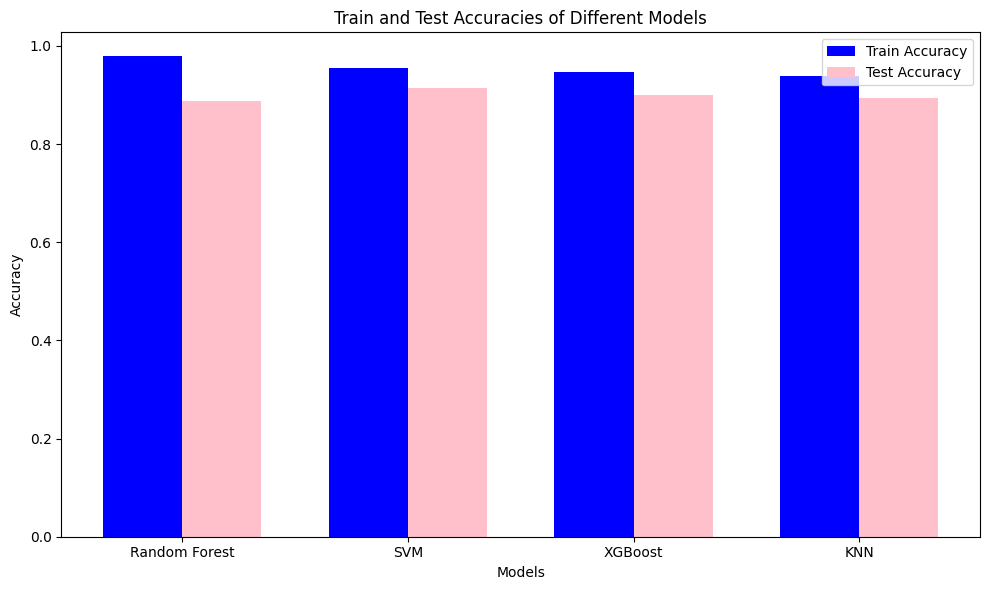

In [39]:
import matplotlib.pyplot as plt

# Train accuracies
train_accuracies = [train_accuracy_rf, train_accuracy_svm, train_accuracy_xgb, train_accuracy_knn]

# Test accuracies
test_accuracies = [test_accuracy_rf1, test_accuracy_svm1, test_accuracy_xgb1, test_accuracy_knn1]

# Model names
models = ['Random Forest', 'SVM', 'XGBoost', 'KNN']

# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.35

# Train accuracies
plt.bar(models, train_accuracies, bar_width, label='Train Accuracy', color='blue')

# Test accuracies
plt.bar([x + bar_width for x in range(len(models))], test_accuracies, bar_width, label='Test Accuracy', color='pink')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracies of Different Models')
plt.xticks([x + bar_width / 2 for x in range(len(models))], models)
plt.legend()
plt.tight_layout()
plt.show()


# Validation

### Preprocessing

**1. Split dataset into features and target**

In [40]:
X_val = Baheya_data.drop('Recurrence Free Status', axis=1)
y_val = Baheya_data['Recurrence Free Status']

**2. Perform one-hot encoding**

In [41]:
categorical_columns = ['Menopausal Status','Tumor Size','Lymph Node Status',
                               'Tumor Grade', 'Histological Type','ER', 'PR',
                               'HER2','Tumor Location','Overall Survival Status']

X_val = pd.get_dummies(X_val, columns=categorical_columns)

**3. Encode labels in target column**

In [42]:
label_encoder = preprocessing.LabelEncoder()
y_val = label_encoder.fit_transform(y_val)

**4. Min Max Scaler**

In [43]:
X_val_scaled = scaler.transform(X_val[['Overall Survival Status (Month)', 'Recurrence Free Status (Month)']])

### Models

**1. Random Forest Model**

In [44]:
y_pred_RF = clf.predict(X_val_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred_RF)
y_val_original = label_encoder.inverse_transform(y_val)

In [45]:
val_accuracy = accuracy_score(y_val_original, y_pred_original)
val_report = classification_report(y_val_original, y_pred_original)

print("Testing Set Accuracy:", val_accuracy)
print("Testing Set Classification Report:\n", val_report)

Testing Set Accuracy: 0.9514384819424607
Testing Set Classification Report:
               precision    recall  f1-score   support

Not Recurred       0.94      0.97      0.95      2560
    Recurred       0.97      0.93      0.95      2341

    accuracy                           0.95      4901
   macro avg       0.95      0.95      0.95      4901
weighted avg       0.95      0.95      0.95      4901



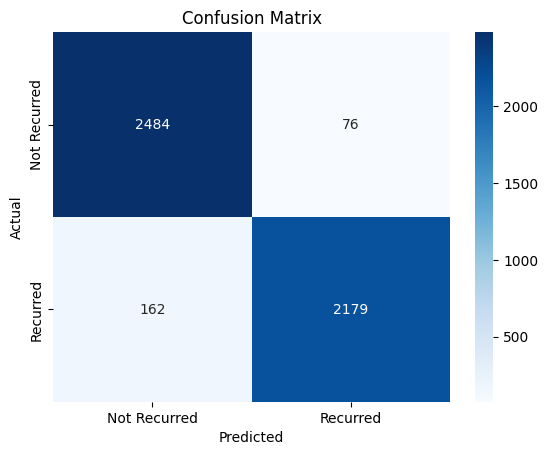

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val_original, y_pred_original)

class_labels = ['Not Recurred', 'Recurred']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


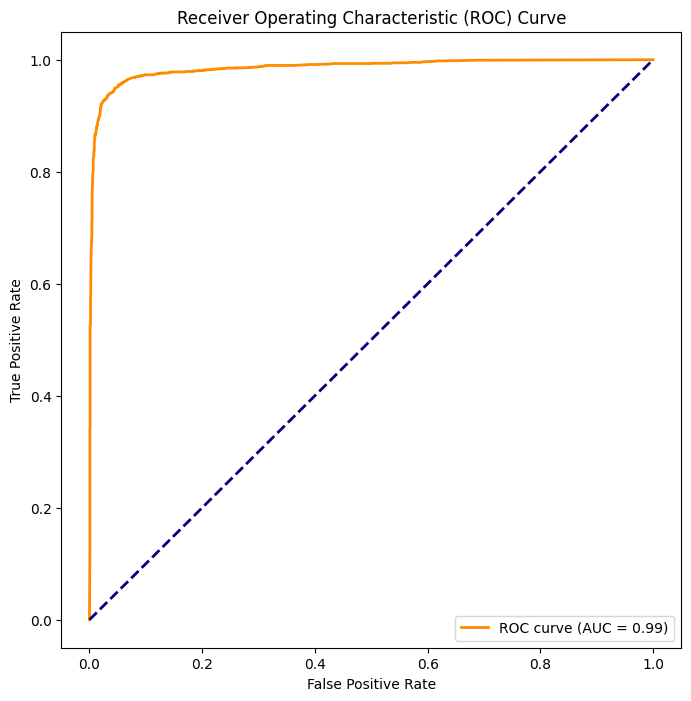

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_pred_proba = clf.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

**2. XGBoost Model**

In [48]:
y_pred_XGB = xgb.predict(X_val_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred_XGB)
y_val_original = label_encoder.inverse_transform(y_val)

In [49]:
val_accuracy = accuracy_score(y_val_original, y_pred_original)
val_report = classification_report(y_val_original, y_pred_original)

print("Testing Set Accuracy:", val_accuracy)
print("Testing Set Classification Report:\n", val_report)

Testing Set Accuracy: 0.9330748826770047
Testing Set Classification Report:
               precision    recall  f1-score   support

Not Recurred       0.91      0.97      0.94      2560
    Recurred       0.96      0.90      0.93      2341

    accuracy                           0.93      4901
   macro avg       0.94      0.93      0.93      4901
weighted avg       0.93      0.93      0.93      4901



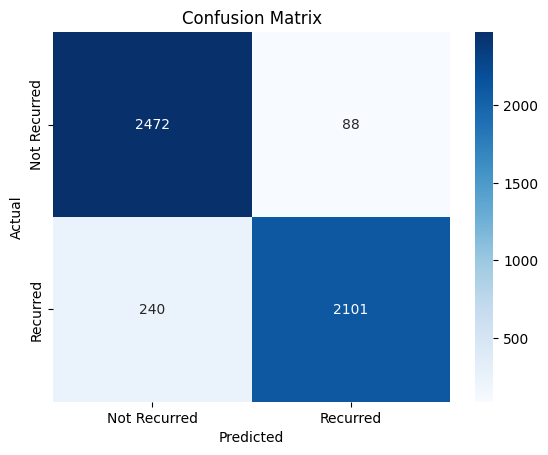

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val_original, y_pred_original)

class_labels = ['Not Recurred', 'Recurred']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

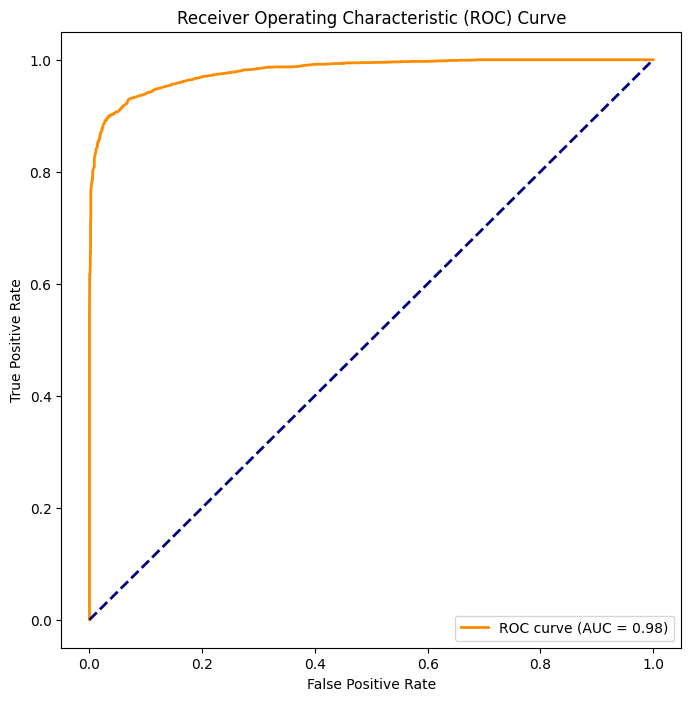

In [51]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_pred_proba = xgb.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

**3. Support Vector Machine Model**

In [52]:
y_pred_SVM = SVM.predict(X_val_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred_SVM)
y_val_original = label_encoder.inverse_transform(y_val)

In [53]:
val_accuracy = accuracy_score(y_val_original, y_pred_original)
val_report = classification_report(y_val_original, y_pred_original)

print("Testing Set Accuracy:", val_accuracy)
print("Testing Set Classification Report:\n", val_report)

Testing Set Accuracy: 0.9426647622934095
Testing Set Classification Report:
               precision    recall  f1-score   support

Not Recurred       0.92      0.97      0.95      2560
    Recurred       0.97      0.91      0.94      2341

    accuracy                           0.94      4901
   macro avg       0.95      0.94      0.94      4901
weighted avg       0.94      0.94      0.94      4901



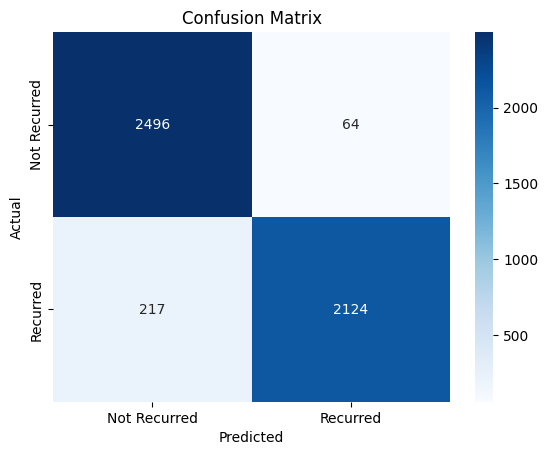

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val_original, y_pred_original)

class_labels = ['Not Recurred', 'Recurred']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

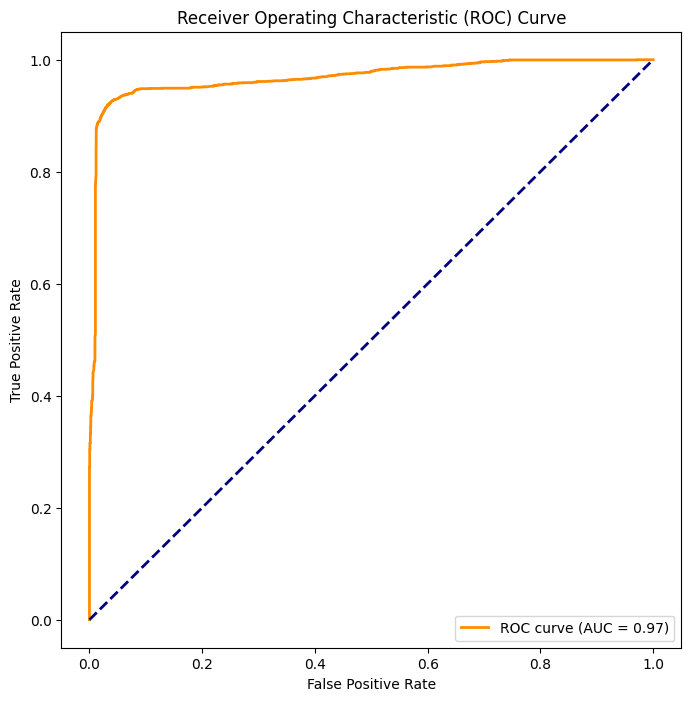

In [55]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming SVM is your SVM classifier and X_val_scaled, y_val are your validation set
y_val_pred_proba = SVM.predict_proba(X_val_scaled)[:, 1] if hasattr(SVM, 'predict_proba') else SVM.decision_function(X_val_scaled)

fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


**4. KNN Model**

In [56]:
y_pred_KNN = knn.predict(X_val_scaled)

y_pred_original = label_encoder.inverse_transform(y_pred_KNN)
y_val_original = label_encoder.inverse_transform(y_val)

In [57]:
val_accuracy = accuracy_score(y_val_original, y_pred_original)
val_report = classification_report(y_val_original, y_pred_original)

print("Testing Set Accuracy:", val_accuracy)
print("Testing Set Classification Report:\n", val_report)

Testing Set Accuracy: 0.9257294429708223
Testing Set Classification Report:
               precision    recall  f1-score   support

Not Recurred       0.90      0.96      0.93      2560
    Recurred       0.95      0.89      0.92      2341

    accuracy                           0.93      4901
   macro avg       0.93      0.92      0.93      4901
weighted avg       0.93      0.93      0.93      4901



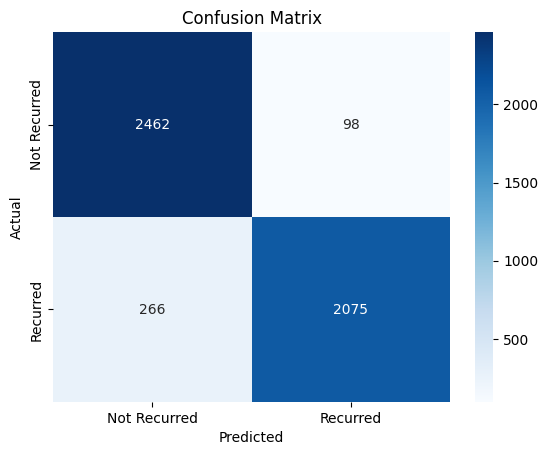

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val_original, y_pred_original)

class_labels = ['Not Recurred', 'Recurred']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

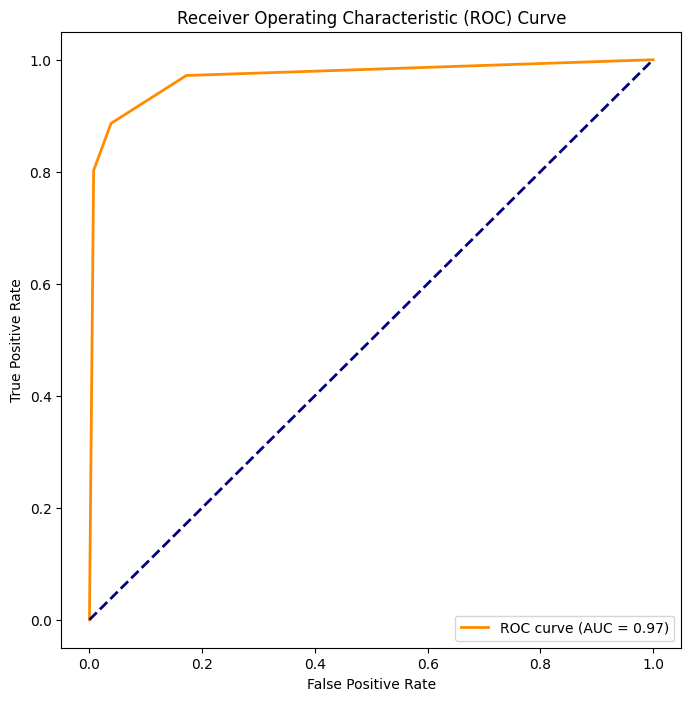

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_pred_proba = knn.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

**5. NN Model**

In [60]:
y_pred_NN = model.predict(X_val_scaled)
val_loss, val_accuracy = model.evaluate(X_val_scaled, y_val)
val_report = classification_report(y_val, (y_pred_NN > 0.5).astype(int))

print(f"Validation Loss: {val_loss:.4f}")
print("Validation Set Accuracy:", val_accuracy)
print("Validation Set Classification Report:\n", val_report)

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8941 - loss: 0.2730
Validation Loss: 0.2730
Validation Set Accuracy: 0.8941032290458679
Validation Set Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90      2560
           1       0.87      0.91      0.89      2341

    accuracy                           0.89      4901
   macro avg       0.89      0.89      0.89      4901
weighted avg       0.90      0.89      0.89      4901



154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


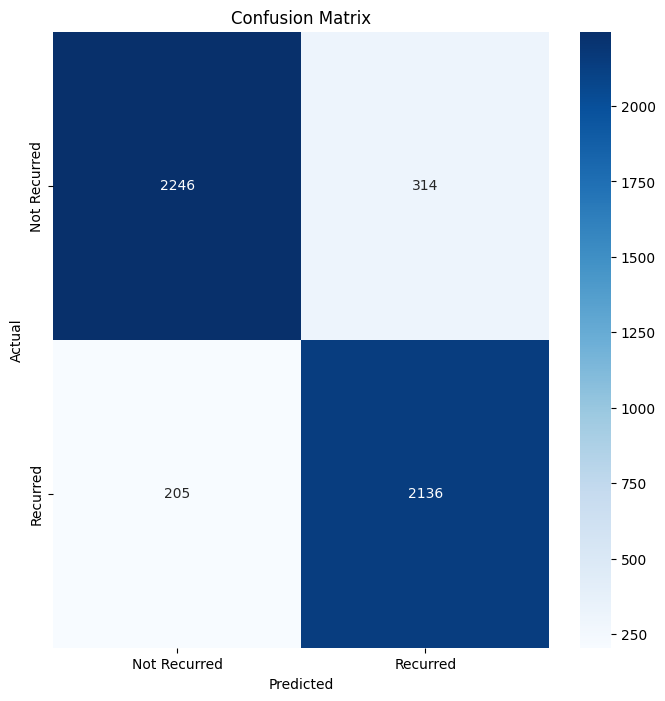

In [61]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_val_pred = (model.predict(X_val_scaled) > 0.5).astype(int)
conf_matrix = confusion_matrix(y_val, y_val_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Recurred', 'Recurred'], yticklabels=['Not Recurred', 'Recurred'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


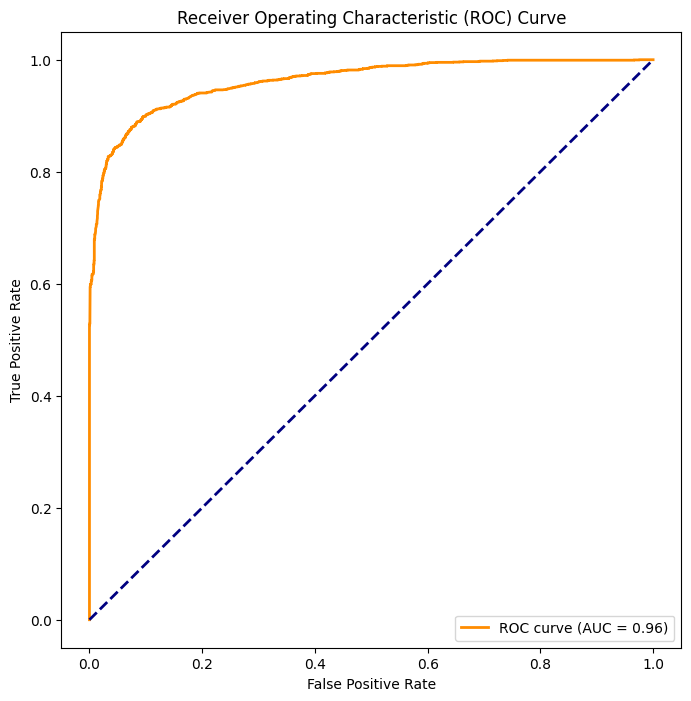

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_val_pred_proba = model.predict(X_val_scaled)[:, 0]
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


**ROC Combined**

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


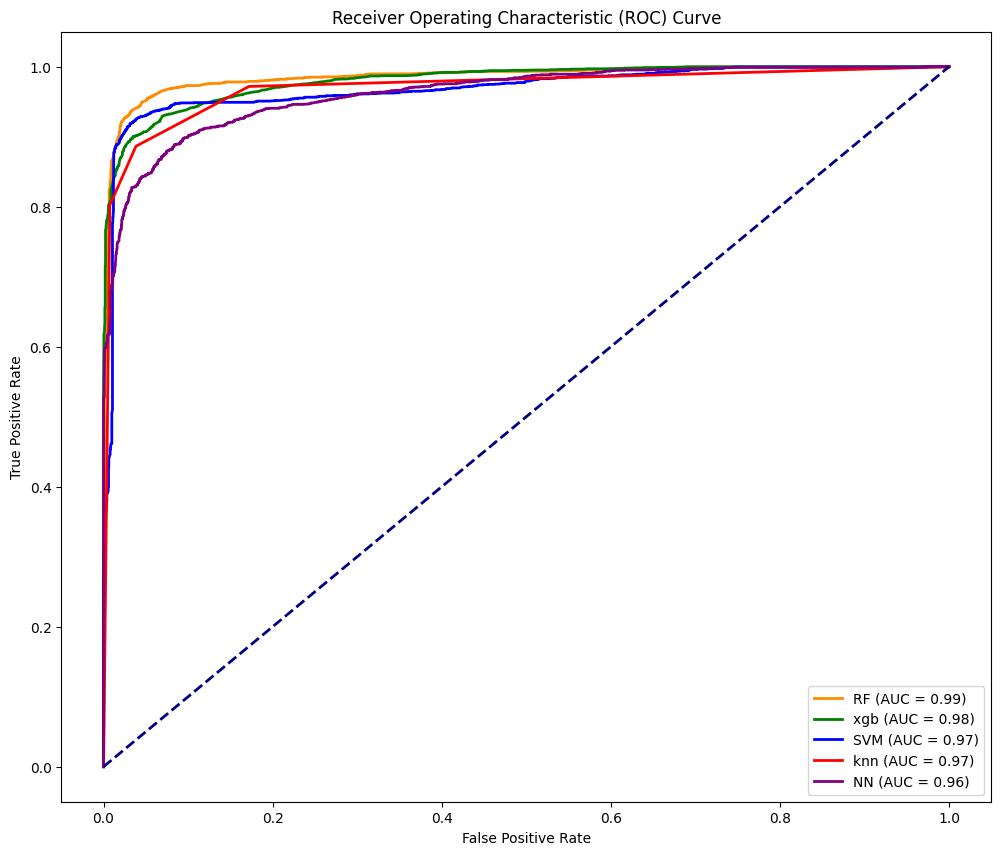

In [63]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plot ROC curve for clf
y_val_pred_proba_clf = clf.predict_proba(X_val_scaled)[:, 1]
fpr_clf, tpr_clf, thresholds_clf = roc_curve(y_val, y_val_pred_proba_clf)
roc_auc_clf = auc(fpr_clf, tpr_clf)


# Plot ROC curve for xgb
y_val_pred_proba_xgb = xgb.predict_proba(X_val_scaled)[:, 1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_val, y_val_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot ROC curve for SVM
y_val_pred_proba_svm = SVM.predict_proba(X_val_scaled)[:, 1] if hasattr(SVM, 'predict_proba') else SVM.decision_function(X_val_scaled)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_val, y_val_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC curve for knn
y_val_pred_proba_knn = knn.predict_proba(X_val_scaled)[:, 1]
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_val, y_val_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plot ROC curve for model
y_val_pred_proba_model = model.predict(X_val_scaled)[:, 0]
fpr_model, tpr_model, thresholds_model = roc_curve(y_val, y_val_pred_proba_model)
roc_auc_model = auc(fpr_model, tpr_model)

# Combine all ROC curves in one plot
plt.figure(figsize=(12, 10))

plt.plot(fpr_clf, tpr_clf, color='darkorange', lw=2, label='RF (AUC = {:.2f})'.format(roc_auc_clf))
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='xgb (AUC = {:.2f})'.format(roc_auc_xgb))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label='SVM (AUC = {:.2f})'.format(roc_auc_svm))
plt.plot(fpr_knn, tpr_knn, color='red', lw=2, label='knn (AUC = {:.2f})'.format(roc_auc_knn))
plt.plot(fpr_model, tpr_model, color='purple', lw=2, label='NN (AUC = {:.2f})'.format(roc_auc_model))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# **Combined Confusion plot**

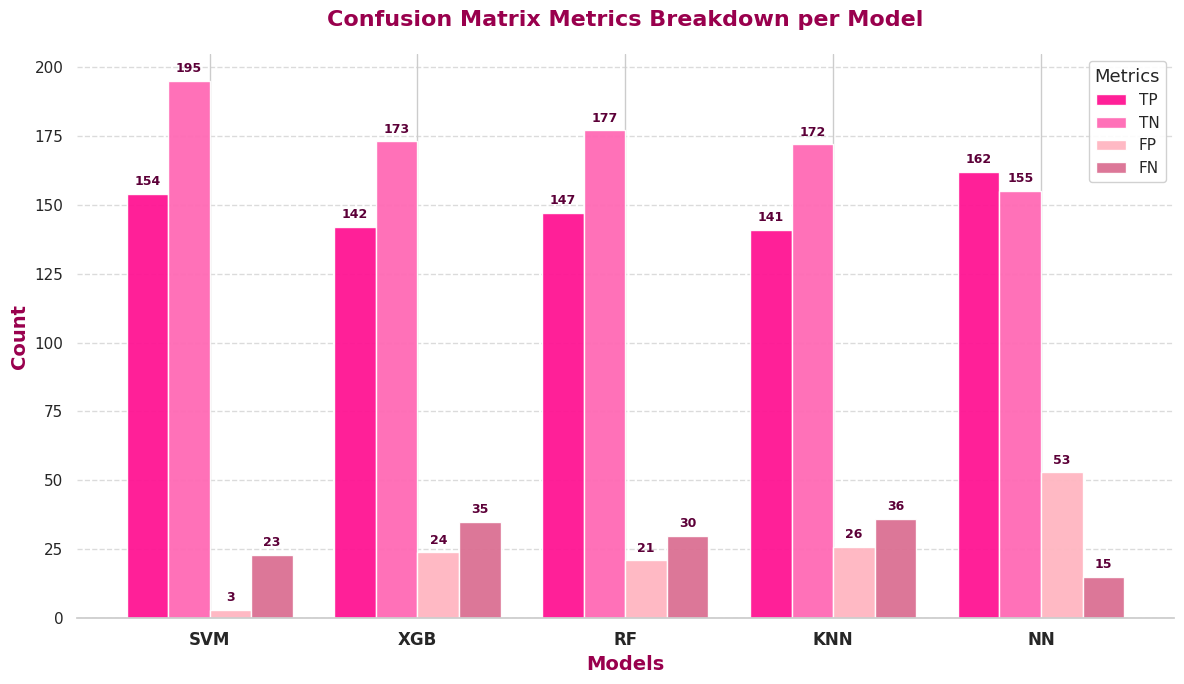

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Data
models = ['SVM', 'XGB', 'RF', 'KNN', 'NN']
metrics = ['TP', 'TN', 'FP', 'FN']
values = np.array([
    [154, 142, 147, 141, 162], # TP
    [195, 173, 177, 172, 155], # TN
    [3, 24, 21, 26, 53],       # FP
    [23, 35, 30, 36, 15]       # FN
])

# Plotting
fig, ax = plt.subplots(figsize=(12, 7)) 

bar_width = 0.2
opacity = 0.95

colors = ['#FF1493', '#FF69B4', '#FFB6C1', '#DB7093']

for i, metric in enumerate(metrics):
    x_positions = np.arange(len(models)) + (i * bar_width)
    rects = ax.bar(x_positions, values[i], bar_width,
                   alpha=opacity, color=colors[i], label=metric, edgecolor='white')
    
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color='#5c0038', weight='bold')

ax.set_xlabel('Models', fontsize=14, color='#99004d', weight='bold')
ax.set_ylabel('Count', fontsize=14, color='#99004d', weight='bold')
ax.set_title('Confusion Matrix Metrics Breakdown per Model', fontsize=16, color='#99004d', weight='bold', pad=20)

ax.set_xticks(np.arange(len(models)) + 1.5 * bar_width)
ax.set_xticklabels(models, fontsize=12, weight='bold')

ax.legend(title='Metrics', title_fontsize='13', fontsize='11', loc='upper right', framealpha=0.9)

sns.despine(left=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True) 

plt.tight_layout()
plt.show()


# Combined evaluation metrics 

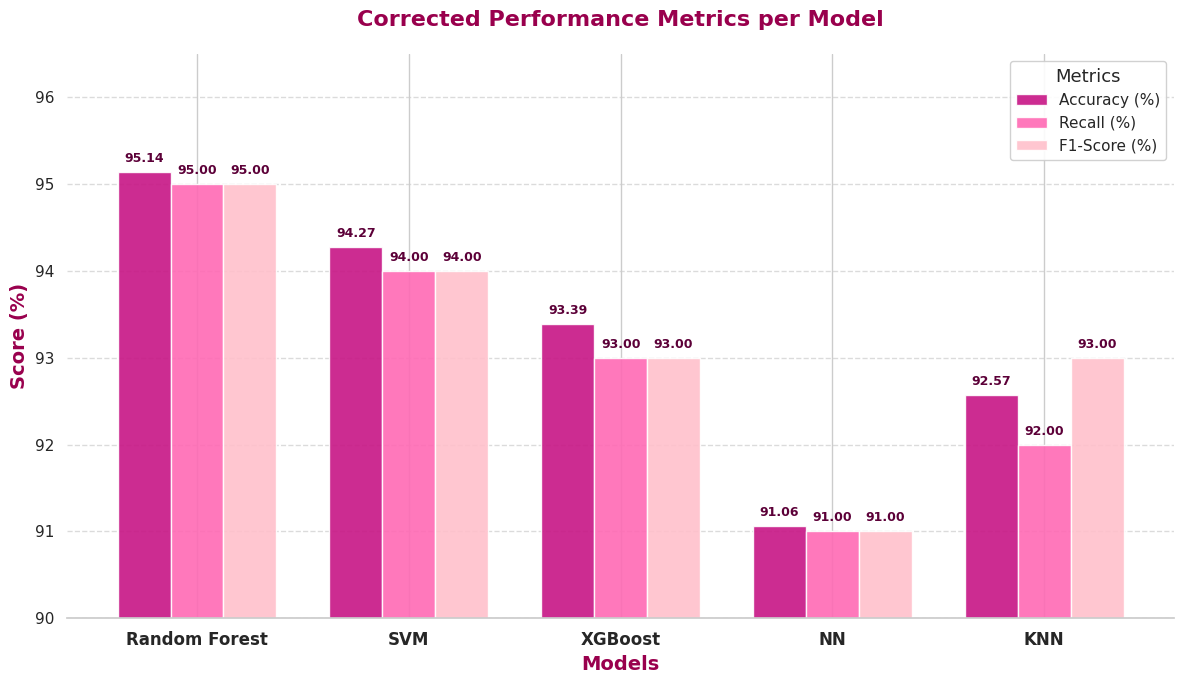

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

models = ['Random Forest', 'SVM', 'XGBoost', 'NN', 'KNN']
metrics = ['Accuracy (%)', 'Recall (%)', 'F1-Score (%)']

values = np.array([
    [95.14, 94.27, 93.39, 91.06, 92.57], # Accuracy
    [95.0,  94.0,  93.0,  91.0,  92.0],  # Recall (Macro Avg)
    [95.0,  94.0,  93.0,  91.0,  93.0]   # F1-Score (Macro Avg)
])

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.25 
opacity = 0.9

colors = ['#C71585', '#FF69B4', '#FFC0CB'] 

for i, metric in enumerate(metrics):
    x_positions = np.arange(len(models)) + (i * bar_width)
    rects = ax.bar(x_positions, values[i], bar_width,
                   alpha=opacity, color=colors[i], label=metric, edgecolor='white')
    
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, color='#5c0038', weight='bold')

ax.set_xlabel('Models', fontsize=14, color='#99004d', weight='bold')
ax.set_ylabel('Score (%)', fontsize=14, color='#99004d', weight='bold')
ax.set_title('Corrected Performance Metrics per Model', fontsize=16, color='#99004d', weight='bold', pad=20)

ax.set_xticks(np.arange(len(models)) + bar_width)
ax.set_xticklabels(models, fontsize=12, weight='bold')

ax.set_ylim(90, 96.5)

ax.legend(title='Metrics', title_fontsize='13', fontsize='11', loc='upper right', framealpha=0.9)

sns.despine(left=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True) 

plt.tight_layout()
plt.show()

# Accuracy Comparison 

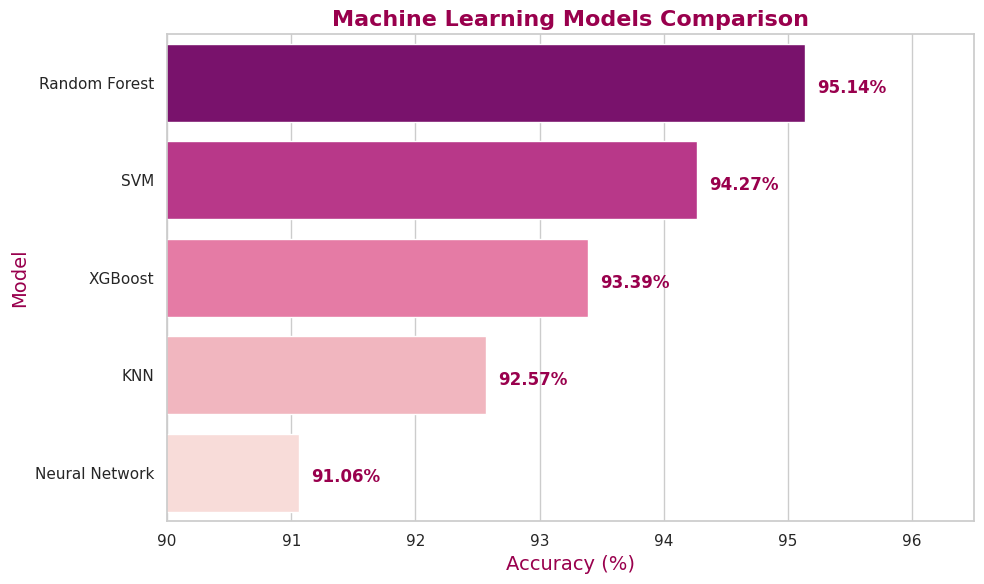

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = {
    'Model': ['Random Forest', 'SVM', 'XGBoost', 'Neural Network', 'KNN'],
    'Accuracy (%)': [95.14, 94.27, 93.39, 91.06, 92.57]
}
df = pd.DataFrame(data)

df = df.sort_values(by='Accuracy (%)', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(x='Accuracy (%)', y='Model', data=df, palette='RdPu_r', hue='Model', legend=False)
plt.title('Machine Learning Models Comparison', fontsize=16, color='#99004d', weight='bold')
plt.xlabel('Accuracy (%)', fontsize=14, color='#99004d')
plt.ylabel('Model', fontsize=14, color='#99004d')

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1, p.get_y() + p.get_height() / 2. + 0.1, 
             f'{width:.2f}%', ha="left", color='#99004d', fontsize=12, weight='bold')

plt.xlim(90, 96.5)

plt.tight_layout()
plt.show()

# **Save the predictions**

In [67]:
import numpy as np

# Assuming y_pred_RF, y_pred_XG, y_pred_SVM, y_pred_KNN, y_pred_NN are the predictions

# Save Random Forest predictions
np.save('y_pred_RF.npy', y_pred_RF)

# Save XGBoost predictions
np.save('y_pred_XG.npy', y_pred_XGB)

# Save SVM predictions
np.save('y_pred_SVM.npy', y_pred_SVM)

# Save KNN predictions
np.save('y_pred_KNN.npy', y_pred_KNN)

# Save Neural Network predictions
np.save('y_pred_NN.npy', y_pred_NN)

In [68]:
print(y_pred_SVM)

[0 0 1 ... 1 0 0]
